In [6]:
print("Environment ready for deforestation project")


Environment ready for deforestation project


In [7]:
!pip install numpy pandas matplotlib rasterio scikit-learn

In [8]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import rasterio

In [ ]:
import os
print(os.listdir(r"C:\Deforestation_Project"))

In [12]:
import os
print(os.listdir(r"C:\Users\RAGA AMIRTHA\Desktop\Deforestation_Project"))

['data', 'models', 'notebooks', 'results']


In [14]:
import os
print(os.getcwd())

C:\Users\RAGA AMIRTHA\Desktop\Deforestation_Project\notebooks


In [15]:
import os
print(os.listdir("../data"))

['extracted', 'labels', 'processed_images', 'raw_data']


In [17]:
print(os.listdir("../data/raw_data"))

['S2A_2019.zip', 'S2A_2020.zip', 'S2A_2021.zip', 'S2A_2022.zip', 'S2A_2023.zip']


In [19]:
import zipfile
import os

zip_folder = "../data/raw_data"
extract_folder = "../data/extracted"

os.makedirs(extract_folder, exist_ok=True)

for file in os.listdir(zip_folder):
    if file.endswith(".zip"):
        zip_path = os.path.join(zip_folder, file)
        with zipfile.ZipFile(zip_path, 'r') as zip_ref:
            zip_ref.extractall(extract_folder)

print("Extraction complete")

Extraction complete


In [20]:
print(os.listdir("../data/extracted"))

['S2A_MSIL1C_20230212T050931_N0510_R019_T43PFM_20240814T095815.SAFE', 'S2A_MSIL2A_20190213T050921_N0500_R019_T43PFM_20221123T192803.SAFE', 'S2A_MSIL2A_20210212T050931_N0500_R019_T43PFM_20230609T084112.SAFE', 'S2B_MSIL1C_20200213T050919_N0500_R019_T43PFM_20230616T001202.SAFE', 'S2B_MSIL2A_20220202T051019_N0510_R019_T43PFM_20240509T162135.SAFE']


In [21]:
import os

dataset = os.listdir("../data/extracted")[0]
print(os.listdir("../data/extracted/" + dataset))

['DATASTRIP', 'GRANULE', 'HTML', 'INSPIRE.xml', 'manifest.safe', 'MTD_MSIL1C.xml', 'rep_info', 'S2A_MSIL1C_20230212T050931_N0510_R019_T43PFM_20240814T095815-ql.jpg']


In [22]:
import os

base_path = "../data/extracted"

# pick the first dataset
dataset = os.listdir(base_path)[0]

dataset_path = os.path.join(base_path, dataset)

print(os.listdir(dataset_path))

['DATASTRIP', 'GRANULE', 'HTML', 'INSPIRE.xml', 'manifest.safe', 'MTD_MSIL1C.xml', 'rep_info', 'S2A_MSIL1C_20230212T050931_N0510_R019_T43PFM_20240814T095815-ql.jpg']


In [23]:
granule_path = os.path.join(dataset_path, "GRANULE")
print(os.listdir(granule_path))

['L1C_T43PFM_A039913_20230212T052542']


In [24]:
tile = os.listdir(granule_path)[0]

img_path = os.path.join(granule_path, tile, "IMG_DATA")

print(os.listdir(img_path))

['T43PFM_20230212T050931_B01.jp2', 'T43PFM_20230212T050931_B02.jp2', 'T43PFM_20230212T050931_B03.jp2', 'T43PFM_20230212T050931_B04.jp2', 'T43PFM_20230212T050931_B05.jp2', 'T43PFM_20230212T050931_B06.jp2', 'T43PFM_20230212T050931_B07.jp2', 'T43PFM_20230212T050931_B08.jp2', 'T43PFM_20230212T050931_B09.jp2', 'T43PFM_20230212T050931_B10.jp2', 'T43PFM_20230212T050931_B11.jp2', 'T43PFM_20230212T050931_B12.jp2', 'T43PFM_20230212T050931_B8A.jp2', 'T43PFM_20230212T050931_TCI.jp2']


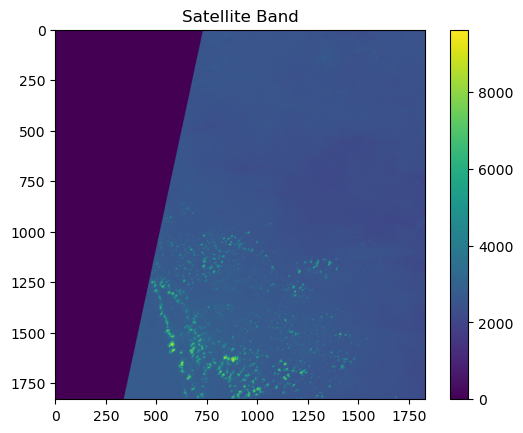

In [25]:
import rasterio
import matplotlib.pyplot as plt

image_file = os.listdir(img_path)[0]
image_path = os.path.join(img_path, image_file)

with rasterio.open(image_path) as src:
    band = src.read(1)

plt.imshow(band)
plt.title("Satellite Band")
plt.colorbar()
plt.show()

In [26]:
files = os.listdir(img_path)

red_file = [f for f in files if "B04" in f][0]
nir_file = [f for f in files if "B08" in f][0]

print("Red band:", red_file)
print("NIR band:", nir_file)

Red band: T43PFM_20230212T050931_B04.jp2
NIR band: T43PFM_20230212T050931_B08.jp2


In [28]:
import numpy as np
import rasterio

red_path = os.path.join(img_path, red_file)
nir_path = os.path.join(img_path, nir_file)

with rasterio.open(red_path) as src:
    red = src.read(1).astype(float)

with rasterio.open(nir_path) as src:
    nir = src.read(1).astype(float)

In [29]:
ndvi = (nir - red) / (nir + red + 1e-6)

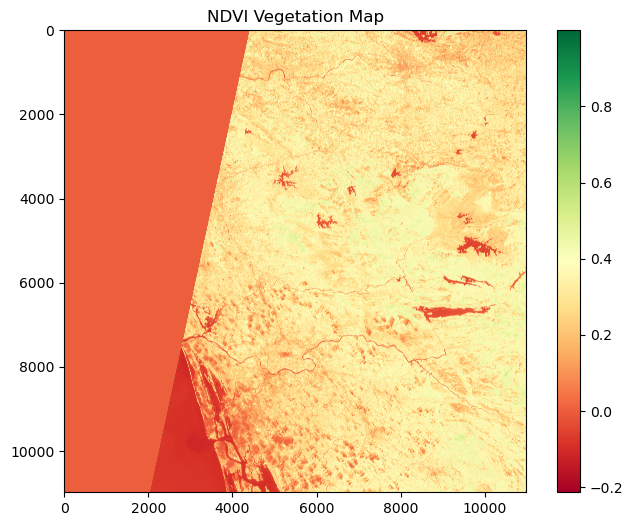

In [30]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
plt.imshow(ndvi, cmap="RdYlGn")
plt.title("NDVI Vegetation Map")
plt.colorbar()
plt.show()

In [31]:
import numpy as np
import rasterio
import os

def calculate_ndvi(img_path):

    files = os.listdir(img_path)

    red_file = [f for f in files if "B04" in f][0]
    nir_file = [f for f in files if "B08" in f][0]

    red_path = os.path.join(img_path, red_file)
    nir_path = os.path.join(img_path, nir_file)

    with rasterio.open(red_path) as src:
        red = src.read(1).astype(float)

    with rasterio.open(nir_path) as src:
        nir = src.read(1).astype(float)

    ndvi = (nir - red) / (nir + red + 1e-6)

    return ndvi

In [42]:
import os

base_path = "../data/extracted"

ndvi_results = {}

datasets = os.listdir(base_path)

for dataset in datasets:

    dataset_path = os.path.join(base_path, dataset)
    granule_path = os.path.join(dataset_path, "GRANULE")

    tile = os.listdir(granule_path)[0]

    img_data_path = os.path.join(granule_path, tile, "IMG_DATA")

    # check if R10m exists
    r10m_path = os.path.join(img_data_path, "R10m")

    if os.path.exists(r10m_path):
        img_path = r10m_path
    else:
        img_path = img_data_path

    ndvi = calculate_ndvi(img_path)

    ndvi_results[dataset] = ndvi

print("NDVI calculated for all datasets")

NDVI calculated for all datasets


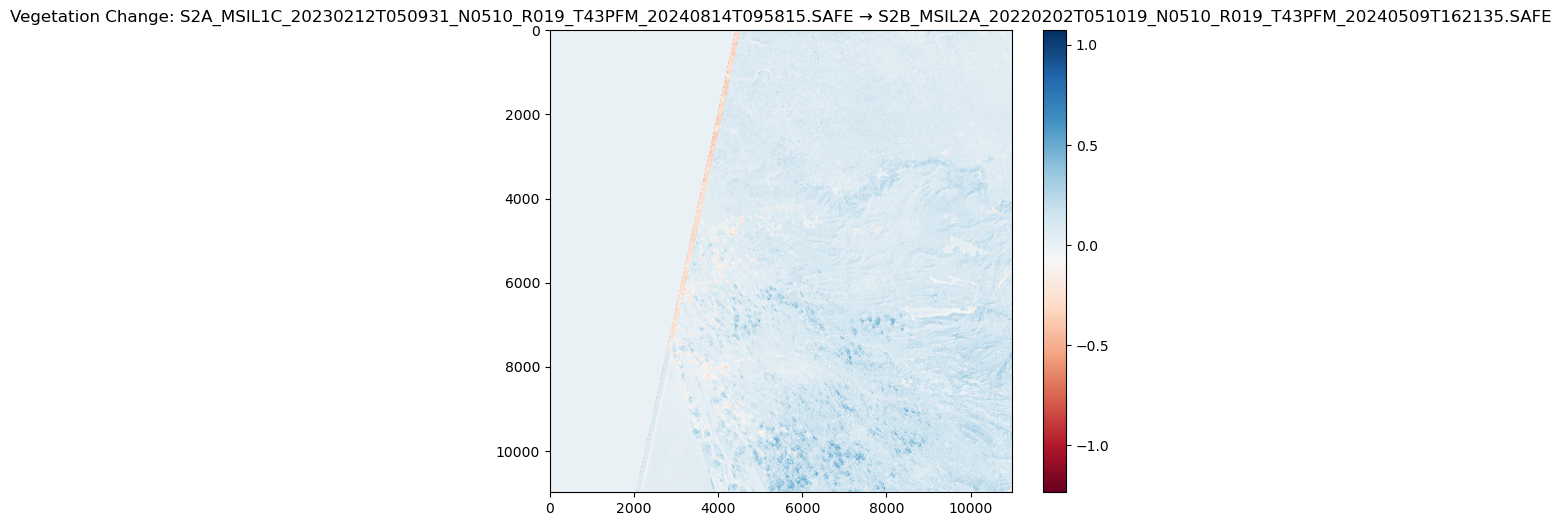

In [33]:
import matplotlib.pyplot as plt

years = list(ndvi_results.keys())

year1 = years[0]
year2 = years[-1]

difference = ndvi_results[year2] - ndvi_results[year1]

plt.figure(figsize=(8,6))
plt.imshow(difference, cmap="RdBu")
plt.title(f"Vegetation Change: {year1} → {year2}")
plt.colorbar()
plt.show()

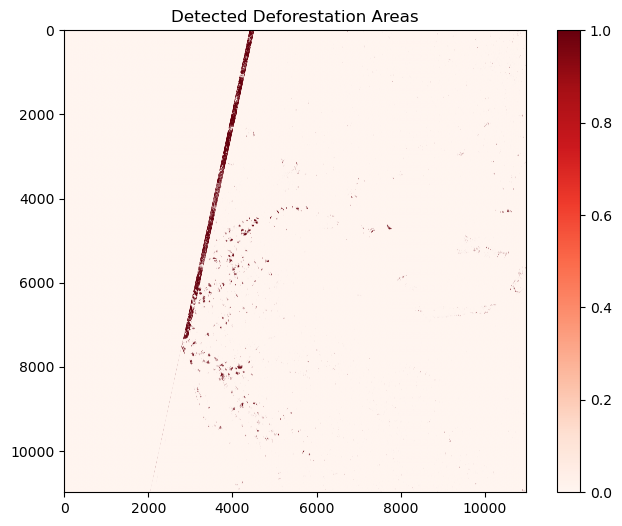

In [34]:
import numpy as np
import matplotlib.pyplot as plt

# threshold for vegetation loss
deforestation = difference < -0.2

plt.figure(figsize=(8,6))
plt.imshow(deforestation, cmap="Reds")
plt.title("Detected Deforestation Areas")
plt.colorbar()
plt.show()

In [36]:
import numpy as np

# ignore extreme NDVI differences (often tile edges)
clean_difference = np.clip(difference, -0.5, 0.5)

deforestation = clean_difference < -0.2

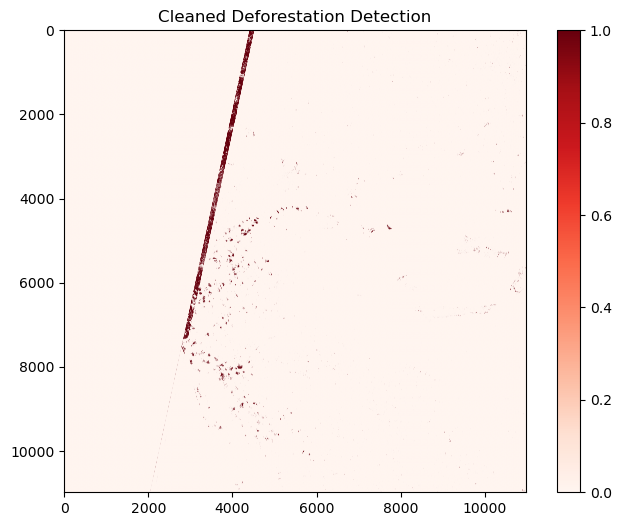

In [37]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
plt.imshow(deforestation, cmap="Reds")
plt.title("Cleaned Deforestation Detection")
plt.colorbar()
plt.show()

In [38]:
pixel_area_m2 = 10 * 10
deforested_pixels = np.sum(deforestation)

area_km2 = (deforested_pixels * pixel_area_m2) / 1e6

print("Estimated deforestation area:", area_km2, "km²")

Estimated deforestation area: 94.067 km²


In [43]:
pixel_area_m2 = 10 * 10
deforested_pixels = np.sum(deforestation)

area_km2 = (deforested_pixels * pixel_area_m2) / 1e6

In [44]:
# only consider areas that were vegetation before
vegetation_mask = ndvi_results[year1] > 0.3

clean_deforestation = (difference < -0.2) & vegetation_mask

In [45]:
pixel_area_m2 = 10 * 10
deforested_pixels = np.sum(clean_deforestation)

area_km2 = (deforested_pixels * pixel_area_m2) / 1e6

print("Refined deforestation area:", area_km2, "km²")

Refined deforestation area: 49.5885 km²


In [46]:
vegetation_mask = ndvi_results[year1] > 0.3
clean_deforestation = (difference < -0.2) & vegetation_mask

In [47]:
import re

years = {}

for dataset in ndvi_results.keys():
    year = re.search(r'_(\d{4})', dataset).group(1)
    years[dataset] = int(year)

print(years)

{'S2A_MSIL1C_20230212T050931_N0510_R019_T43PFM_20240814T095815.SAFE': 2023, 'S2A_MSIL2A_20190213T050921_N0500_R019_T43PFM_20221123T192803.SAFE': 2019, 'S2A_MSIL2A_20210212T050931_N0500_R019_T43PFM_20230609T084112.SAFE': 2021, 'S2B_MSIL1C_20200213T050919_N0500_R019_T43PFM_20230616T001202.SAFE': 2020, 'S2B_MSIL2A_20220202T051019_N0510_R019_T43PFM_20240509T162135.SAFE': 2022}


In [48]:
sorted_datasets = sorted(ndvi_results.keys(), key=lambda x: years[x])

print(sorted_datasets)

['S2A_MSIL2A_20190213T050921_N0500_R019_T43PFM_20221123T192803.SAFE', 'S2B_MSIL1C_20200213T050919_N0500_R019_T43PFM_20230616T001202.SAFE', 'S2A_MSIL2A_20210212T050931_N0500_R019_T43PFM_20230609T084112.SAFE', 'S2B_MSIL2A_20220202T051019_N0510_R019_T43PFM_20240509T162135.SAFE', 'S2A_MSIL1C_20230212T050931_N0510_R019_T43PFM_20240814T095815.SAFE']


In [50]:
data_dir = "../data/extracted"

datasets = os.listdir(data_dir)

ndvi_results = {}

for dataset in datasets:

    granule_path = os.path.join(data_dir, dataset, "GRANULE")
    tile = os.listdir(granule_path)[0]

    img_data_path = os.path.join(granule_path, tile, "IMG_DATA")

    # check if R10m folder exists
    r10m_path = os.path.join(img_data_path, "R10m")

    if os.path.exists(r10m_path):
        img_path = r10m_path
    else:
        img_path = img_data_path

    ndvi = calculate_ndvi(img_path)

    ndvi_results[dataset] = ndvi

print("NDVI calculated for all datasets")

NDVI calculated for all datasets


In [51]:
year1 = list(ndvi_results.keys())[0]
year2 = list(ndvi_results.keys())[1]

difference = ndvi_results[year2] - ndvi_results[year1]

print("Comparing:", year1, "vs", year2)

Comparing: S2A_MSIL1C_20230212T050931_N0510_R019_T43PFM_20240814T095815.SAFE vs S2A_MSIL2A_20190213T050921_N0500_R019_T43PFM_20221123T192803.SAFE


In [58]:
deforestation_mask = difference < -0.2

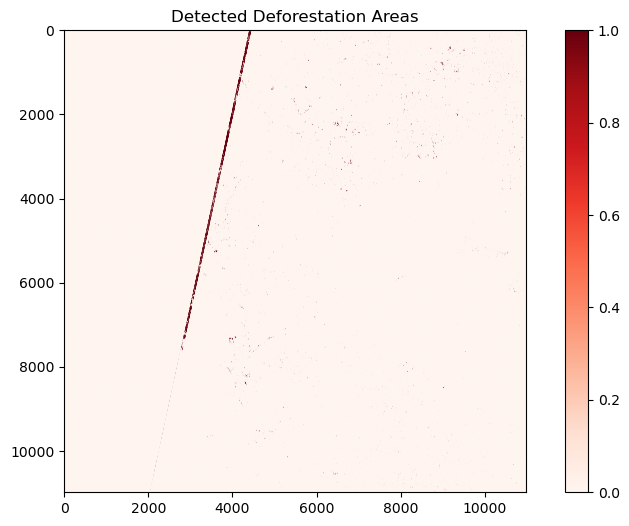

In [59]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
plt.imshow(deforestation_mask, cmap="Reds")

plt.title("Detected Deforestation Areas")
plt.colorbar()

plt.show()

In [63]:
plt.savefig("../results/deforestation_map.png", dpi=300)

<Figure size 640x480 with 0 Axes>

In [64]:
import numpy as np

# stack NDVI arrays
ndvi_stack = np.stack(list(ndvi_results.values()), axis=0)

print("NDVI stack shape:", ndvi_stack.shape)

NDVI stack shape: (5, 10980, 10980)


In [65]:
X = ndvi_stack.astype(np.float32)

# add batch dimension
X = np.expand_dims(X, axis=0)

print(X.shape)

(1, 5, 10980, 10980)


In [66]:
import torch
import torch.nn as nn
import torch.nn.functional as F

In [67]:
class UNet(nn.Module):

    def __init__(self, in_channels=5, out_channels=1):
        super(UNet, self).__init__()

        self.enc1 = nn.Sequential(
            nn.Conv2d(in_channels, 32, 3, padding=1),
            nn.ReLU(),
            nn.Conv2d(32, 32, 3, padding=1),
            nn.ReLU()
        )

        self.pool = nn.MaxPool2d(2)

        self.enc2 = nn.Sequential(
            nn.Conv2d(32, 64, 3, padding=1),
            nn.ReLU(),
            nn.Conv2d(64, 64, 3, padding=1),
            nn.ReLU()
        )

        self.up = nn.ConvTranspose2d(64, 32, 2, stride=2)

        self.dec1 = nn.Sequential(
            nn.Conv2d(64, 32, 3, padding=1),
            nn.ReLU(),
            nn.Conv2d(32, 32, 3, padding=1),
            nn.ReLU()
        )

        self.final = nn.Conv2d(32, out_channels, 1)

    def forward(self, x):

        e1 = self.enc1(x)
        p1 = self.pool(e1)

        e2 = self.enc2(p1)

        up1 = self.up(e2)

        concat = torch.cat([up1, e1], dim=1)

        d1 = self.dec1(concat)

        out = torch.sigmoid(self.final(d1))

        return out

In [68]:
print(UNet)

<class '__main__.UNet'>


In [69]:
import os
import numpy as np
import rasterio

In [70]:
def calculate_ndvi(img_path):
    files = os.listdir(img_path)

    red_candidates = [f for f in files if "B04" in f]
    nir_candidates = [f for f in files if "B08" in f]

    if len(red_candidates) == 0 or len(nir_candidates) == 0:
        raise ValueError(f"B04/B08 not found in: {img_path}")

    red_file = red_candidates[0]
    nir_file = nir_candidates[0]

    red_path = os.path.join(img_path, red_file)
    nir_path = os.path.join(img_path, nir_file)

    with rasterio.open(red_path) as red_src:
        red = red_src.read(1).astype(float)

    with rasterio.open(nir_path) as nir_src:
        nir = nir_src.read(1).astype(float)

    ndvi = (nir - red) / (nir + red + 1e-5)
    return ndvi

In [71]:
data_dir = "../data/extracted"
datasets = os.listdir(data_dir)

ndvi_results = {}

for dataset in datasets:
    granule_path = os.path.join(data_dir, dataset, "GRANULE")
    tile = os.listdir(granule_path)[0]

    img_data_path = os.path.join(granule_path, tile, "IMG_DATA")
    r10m_path = os.path.join(img_data_path, "R10m")

    if os.path.exists(r10m_path):
        img_path = r10m_path
    else:
        img_path = img_data_path

    ndvi = calculate_ndvi(img_path)
    ndvi_results[dataset] = ndvi

print("NDVI calculated for all datasets")
print("Number of datasets:", len(ndvi_results))

NDVI calculated for all datasets
Number of datasets: 5


In [72]:
ndvi_stack = np.stack(list(ndvi_results.values()), axis=0)
print("NDVI stack shape:", ndvi_stack.shape)

NDVI stack shape: (5, 10980, 10980)


In [73]:
X = ndvi_stack.astype(np.float32)
X = np.expand_dims(X, axis=0)
print("Input shape:", X.shape)

Input shape: (1, 5, 10980, 10980)


In [74]:
import torch

X_tensor = torch.tensor(X, dtype=torch.float32)
print(X_tensor.shape)

torch.Size([1, 5, 10980, 10980])


In [75]:
patch_size = 256
stride = 256

patches = []

_, channels, height, width = X.shape

for i in range(0, height - patch_size + 1, stride):
    for j in range(0, width - patch_size + 1, stride):
        patch = X[:, :, i:i+patch_size, j:j+patch_size]
        patches.append(patch)

print("Number of patches:", len(patches))
print("One patch shape:", patches[0].shape)

Number of patches: 1764
One patch shape: (1, 5, 256, 256)


In [76]:
sample_patch = torch.tensor(patches[0], dtype=torch.float32)

print(sample_patch.shape)

torch.Size([1, 5, 256, 256])


In [77]:
import os
import numpy as np
import rasterio
import matplotlib.pyplot as plt
import torch
import torch.nn as nn

In [78]:
DATA_DIR = "../data/extracted"
PATCH_SIZE = 256
STRIDE = 256

In [79]:
def calculate_ndvi(image_folder):
    files = os.listdir(image_folder)

    red_files = [f for f in files if "B04" in f]
    nir_files = [f for f in files if "B08" in f]

    if len(red_files) == 0 or len(nir_files) == 0:
        raise ValueError(f"B04 or B08 not found in: {image_folder}")

    red_path = os.path.join(image_folder, red_files[0])
    nir_path = os.path.join(image_folder, nir_files[0])

    with rasterio.open(red_path) as src:
        red = src.read(1).astype(np.float32)

    with rasterio.open(nir_path) as src:
        nir = src.read(1).astype(np.float32)

    ndvi = (nir - red) / (nir + red + 1e-5)
    return ndvi

In [83]:
ndvi_stack = np.stack(list(ndvi_results.values()), axis=0)

print("NDVI stack shape:", ndvi_stack.shape)

NDVI stack shape: (5, 10980, 10980)


In [84]:
X_np = ndvi_stack.astype(np.float32)
X_np = np.expand_dims(X_np, axis=0)

print("Model input shape:", X_np.shape)

Model input shape: (1, 5, 10980, 10980)


In [85]:
patches_np = []

_, channels, height, width = X_np.shape

for i in range(0, height - PATCH_SIZE + 1, STRIDE):
    for j in range(0, width - PATCH_SIZE + 1, STRIDE):

        patch = X_np[:, :, i:i+PATCH_SIZE, j:j+PATCH_SIZE]

        patches_np.append(patch)

print("Number of patches:", len(patches_np))
print("Patch shape:", patches_np[0].shape)

Number of patches: 1764
Patch shape: (1, 5, 256, 256)


In [86]:
sample_patch = torch.tensor(patches_np[0], dtype=torch.float32)

print("sample_patch shape:", sample_patch.shape)

sample_patch shape: torch.Size([1, 5, 256, 256])


In [87]:
class UNet(nn.Module):

    def __init__(self, in_channels=5, out_channels=1):
        super().__init__()

        self.enc1 = nn.Sequential(
            nn.Conv2d(in_channels, 32, 3, padding=1),
            nn.ReLU(),
            nn.Conv2d(32, 32, 3, padding=1),
            nn.ReLU()
        )

        self.pool = nn.MaxPool2d(2)

        self.enc2 = nn.Sequential(
            nn.Conv2d(32, 64, 3, padding=1),
            nn.ReLU(),
            nn.Conv2d(64, 64, 3, padding=1),
            nn.ReLU()
        )

        self.up = nn.ConvTranspose2d(64, 32, 2, stride=2)

        self.dec1 = nn.Sequential(
            nn.Conv2d(64, 32, 3, padding=1),
            nn.ReLU(),
            nn.Conv2d(32, 32, 3, padding=1),
            nn.ReLU()
        )

        self.final = nn.Conv2d(32, out_channels, 1)

    def forward(self, x):

        e1 = self.enc1(x)
        p1 = self.pool(e1)

        e2 = self.enc2(p1)

        up1 = self.up(e2)

        concat = torch.cat([up1, e1], dim=1)

        d1 = self.dec1(concat)

        out = torch.sigmoid(self.final(d1))

        return out

In [88]:
model = UNet(in_channels=5, out_channels=1)

print(type(model))

<class '__main__.UNet'>


In [89]:
with torch.no_grad():
    pred_patch = model(sample_patch)

print("Prediction shape:", pred_patch.shape)

Prediction shape: torch.Size([1, 1, 256, 256])


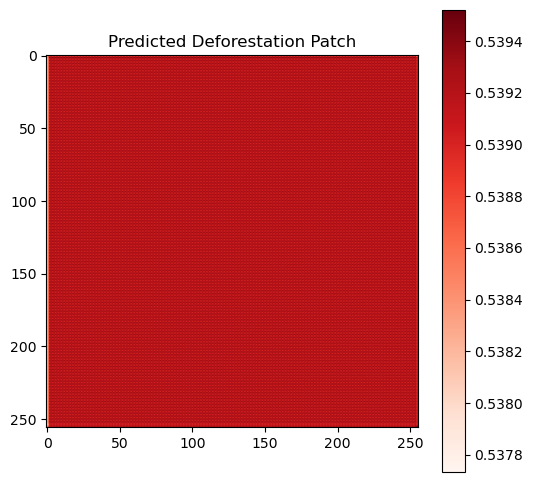

In [90]:
plt.figure(figsize=(6,6))
plt.imshow(pred_patch[0,0].numpy(), cmap="Reds")
plt.title("Predicted Deforestation Patch")
plt.colorbar()
plt.show()

In [91]:
import os

print("Files in labels folder:")
print(os.listdir("../data/labels"))

Files in labels folder:
['datamask.tif', 'lossyear.tif', 'treecover2000.tif']


In [92]:
import os
import rasterio
import numpy as np

LABEL_DIR = "../data/labels"

loss_file = os.path.join(LABEL_DIR, "lossyear.tif")
treecover_file = os.path.join(LABEL_DIR, "treecover2000.tif")
datamask_file = os.path.join(LABEL_DIR, "datamask.tif")

print("Loss file:", loss_file)
print("Tree cover file:", treecover_file)
print("Data mask file:", datamask_file)

with rasterio.open(loss_file) as src:
    loss_year = src.read(1)

with rasterio.open(treecover_file) as src:
    tree_cover = src.read(1)

with rasterio.open(datamask_file) as src:
    data_mask = src.read(1)

print("loss_year shape:", loss_year.shape)
print("tree_cover shape:", tree_cover.shape)
print("data_mask shape:", data_mask.shape)

Loss file: ../data/labels\lossyear.tif
Tree cover file: ../data/labels\treecover2000.tif
Data mask file: ../data/labels\datamask.tif
loss_year shape: (40000, 40000)
tree_cover shape: (40000, 40000)
data_mask shape: (40000, 40000)


In [93]:
label_map_full = ((loss_year > 0) & (tree_cover > 30) & (data_mask == 1)).astype(np.float32)

print("Full label map shape:", label_map_full.shape)
print("Total deforestation pixels:", np.sum(label_map_full))

Full label map shape: (40000, 40000)
Total deforestation pixels: 1.029867e+06


In [94]:
ndvi_height = ndvi_stack.shape[1]
ndvi_width = ndvi_stack.shape[2]

label_map = label_map_full[:ndvi_height, :ndvi_width]

print("Cropped label map shape:", label_map.shape)
print("NDVI image shape:", (ndvi_height, ndvi_width))

Cropped label map shape: (10980, 10980)
NDVI image shape: (10980, 10980)


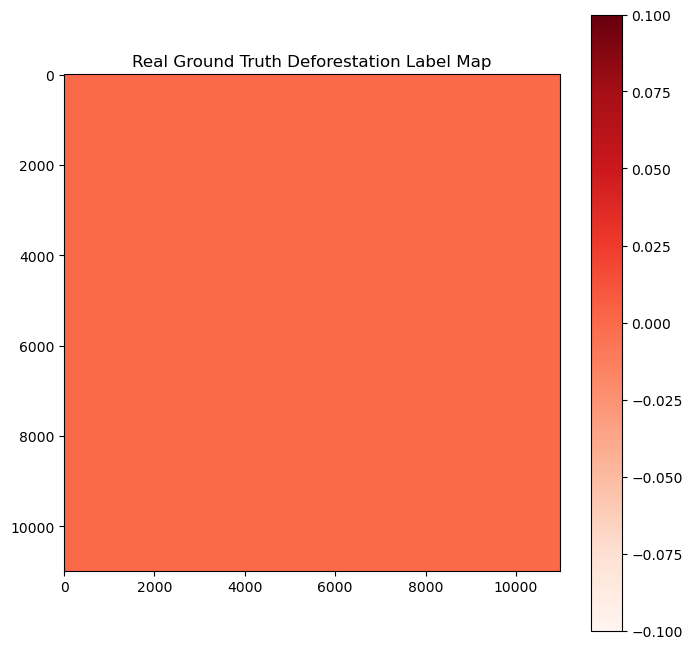

In [95]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 8))
plt.imshow(label_map, cmap="Reds")
plt.title("Real Ground Truth Deforestation Label Map")
plt.colorbar()
plt.show()

In [96]:
label_patches = []

height, width = label_map.shape

for i in range(0, height - PATCH_SIZE + 1, STRIDE):
    for j in range(0, width - PATCH_SIZE + 1, STRIDE):
        patch = label_map[i:i+PATCH_SIZE, j:j+PATCH_SIZE]
        label_patches.append(patch)

print("Number of label patches:", len(label_patches))
print("One label patch shape:", label_patches[0].shape)

Number of label patches: 1764
One label patch shape: (256, 256)


In [97]:
import torch

X_train = torch.tensor(np.concatenate(patches_np, axis=0), dtype=torch.float32)

Y_train = torch.tensor(np.array(label_patches), dtype=torch.float32)
Y_train = Y_train.unsqueeze(1)

print("X_train shape:", X_train.shape)
print("Y_train shape:", Y_train.shape)

X_train shape: torch.Size([1764, 5, 256, 256])
Y_train shape: torch.Size([1764, 1, 256, 256])


In [98]:
print("Cropped label map shape:", label_map.shape)
print("X_train shape:", X_train.shape)
print("Y_train shape:", Y_train.shape)

Cropped label map shape: (10980, 10980)
X_train shape: torch.Size([1764, 5, 256, 256])
Y_train shape: torch.Size([1764, 1, 256, 256])


In [99]:
import torch
import torch.nn as nn

class UNet(nn.Module):
    def __init__(self, in_channels=5, out_channels=1):
        super().__init__()

        self.enc1 = nn.Sequential(
            nn.Conv2d(in_channels, 32, 3, padding=1),
            nn.ReLU(),
            nn.Conv2d(32, 32, 3, padding=1),
            nn.ReLU()
        )

        self.pool1 = nn.MaxPool2d(2)

        self.enc2 = nn.Sequential(
            nn.Conv2d(32, 64, 3, padding=1),
            nn.ReLU(),
            nn.Conv2d(64, 64, 3, padding=1),
            nn.ReLU()
        )

        self.up1 = nn.ConvTranspose2d(64, 32, 2, stride=2)

        self.dec1 = nn.Sequential(
            nn.Conv2d(64, 32, 3, padding=1),
            nn.ReLU(),
            nn.Conv2d(32, 32, 3, padding=1),
            nn.ReLU()
        )

        self.final = nn.Conv2d(32, out_channels, 1)

    def forward(self, x):
        e1 = self.enc1(x)
        p1 = self.pool1(e1)

        e2 = self.enc2(p1)

        u1 = self.up1(e2)
        cat = torch.cat([u1, e1], dim=1)

        d1 = self.dec1(cat)
        out = torch.sigmoid(self.final(d1))

        return out

model = UNet(in_channels=5, out_channels=1)
print(type(model))

<class '__main__.UNet'>


In [100]:
criterion = nn.BCELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

In [101]:
from torch.utils.data import TensorDataset, DataLoader

train_dataset = TensorDataset(X_train, Y_train)
train_loader = DataLoader(train_dataset, batch_size=8, shuffle=True)

print("Number of batches:", len(train_loader))

Number of batches: 221


In [ ]:
criterion = nn.BCELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

epochs = 3

for epoch in range(epochs):
    model.train()
    epoch_loss = 0.0

    for batch_x, batch_y in train_loader:
        optimizer.zero_grad()

        outputs = model(batch_x)
        loss = criterion(outputs, batch_y)

        loss.backward()
        optimizer.step()

        epoch_loss += loss.item()

    avg_loss = epoch_loss / len(train_loader)
    print(f"Epoch {epoch+1}/{epochs}, Loss: {avg_loss:.6f}")

In [103]:
sample_patch = X_train[0:1]

model.eval()
with torch.no_grad():
    pred_patch = model(sample_patch)

print("pred_patch shape:", pred_patch.shape)
print("Prediction min:", pred_patch.min().item())
print("Prediction max:", pred_patch.max().item())

pred_patch shape: torch.Size([1, 1, 256, 256])
Prediction min: 0.0
Prediction max: 3.704106887880698e-08


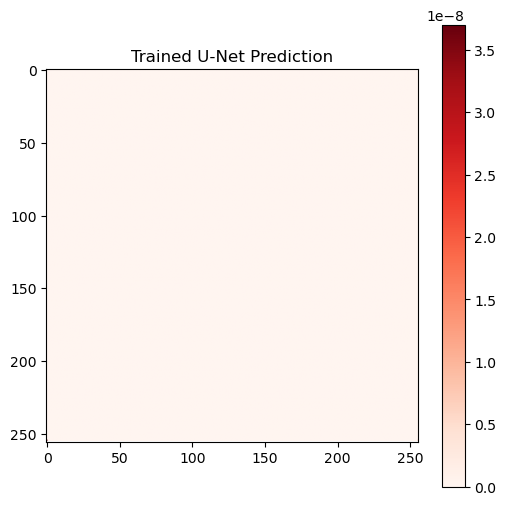

In [104]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 6))
plt.imshow(pred_patch[0, 0].numpy(), cmap="Reds")
plt.title("Trained U-Net Prediction")
plt.colorbar()
plt.show()

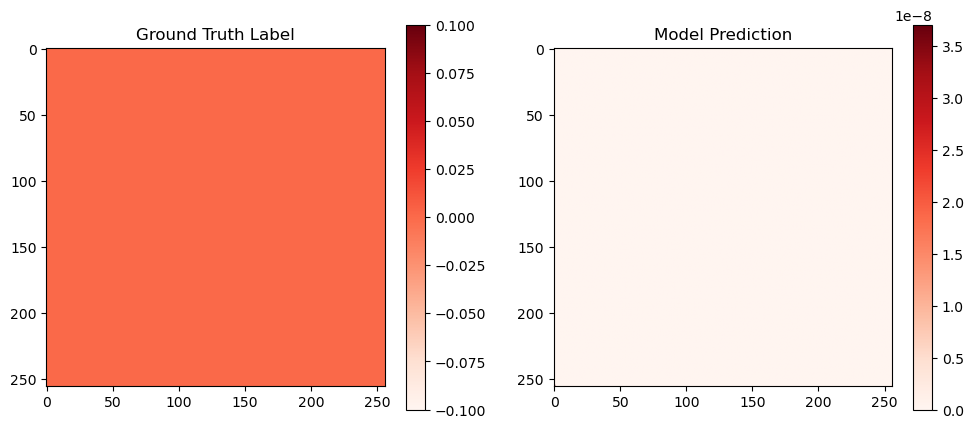

In [105]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.imshow(Y_train[0, 0].numpy(), cmap="Reds")
plt.title("Ground Truth Label")
plt.colorbar()

plt.subplot(1, 2, 2)
plt.imshow(pred_patch[0, 0].numpy(), cmap="Reds")
plt.title("Model Prediction")
plt.colorbar()

plt.show()

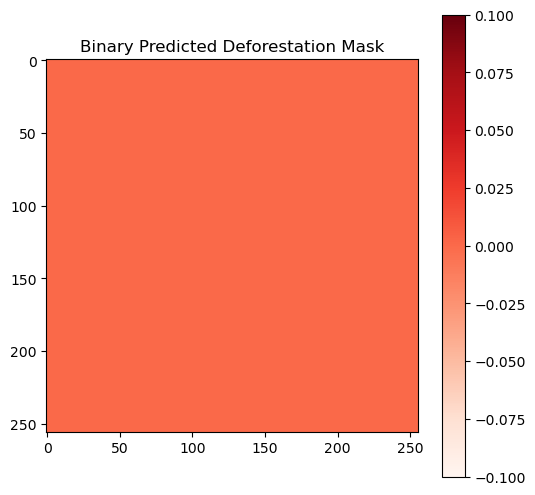

In [106]:
pred_binary = (pred_patch[0, 0].numpy() > 0.5).astype(np.float32)

plt.figure(figsize=(6, 6))
plt.imshow(pred_binary, cmap="Reds")
plt.title("Binary Predicted Deforestation Mask")
plt.colorbar()
plt.show()

In [107]:
positive_counts = [patch.sum() for patch in label_patches]

print("Minimum positive pixels:", np.min(positive_counts))
print("Maximum positive pixels:", np.max(positive_counts))
print("Number of empty patches:", np.sum(np.array(positive_counts) == 0))
print("Total patches:", len(positive_counts))

Minimum positive pixels: 0.0
Maximum positive pixels: 0.0
Number of empty patches: 1764
Total patches: 1764


In [113]:
import os

DATA_DIR = "../data/extracted"

dataset_names = os.listdir(DATA_DIR)
print("Datasets:", dataset_names)

# pick first dataset
reference_dataset_name = dataset_names[0]

granule_dir = os.path.join(DATA_DIR, reference_dataset_name, "GRANULE")
tile_name = os.listdir(granule_dir)[0]

img_data_dir = os.path.join(granule_dir, tile_name, "IMG_DATA")
r10m_dir = os.path.join(img_data_dir, "R10m")

# choose correct folder
if os.path.exists(r10m_dir):
    reference_folder = r10m_dir
else:
    reference_folder = img_data_dir

files = os.listdir(reference_folder)

# pick red band (B04)
reference_red_file = [f for f in files if "B04" in f][0]
reference_red_path = os.path.join(reference_folder, reference_red_file)

print("Reference file:", reference_red_path)

Datasets: ['S2A_MSIL1C_20230212T050931_N0510_R019_T43PFM_20240814T095815.SAFE', 'S2A_MSIL2A_20190213T050921_N0500_R019_T43PFM_20221123T192803.SAFE', 'S2A_MSIL2A_20210212T050931_N0500_R019_T43PFM_20230609T084112.SAFE', 'S2B_MSIL1C_20200213T050919_N0500_R019_T43PFM_20230616T001202.SAFE', 'S2B_MSIL2A_20220202T051019_N0510_R019_T43PFM_20240509T162135.SAFE']
Reference file: ../data/extracted\S2A_MSIL1C_20230212T050931_N0510_R019_T43PFM_20240814T095815.SAFE\GRANULE\L1C_T43PFM_A039913_20230212T052542\IMG_DATA\T43PFM_20230212T050931_B04.jp2


In [114]:
import os

DATA_DIR = "../data/extracted"

dataset_names = os.listdir(DATA_DIR)
print("Datasets:", dataset_names)

# pick first dataset
reference_dataset_name = dataset_names[0]

granule_dir = os.path.join(DATA_DIR, reference_dataset_name, "GRANULE")
tile_name = os.listdir(granule_dir)[0]

img_data_dir = os.path.join(granule_dir, tile_name, "IMG_DATA")
r10m_dir = os.path.join(img_data_dir, "R10m")

# choose correct folder
if os.path.exists(r10m_dir):
    reference_folder = r10m_dir
else:
    reference_folder = img_data_dir

files = os.listdir(reference_folder)

# pick red band (B04)
reference_red_file = [f for f in files if "B04" in f][0]
reference_red_path = os.path.join(reference_folder, reference_red_file)

print("Reference file:", reference_red_path)

Datasets: ['S2A_MSIL1C_20230212T050931_N0510_R019_T43PFM_20240814T095815.SAFE', 'S2A_MSIL2A_20190213T050921_N0500_R019_T43PFM_20221123T192803.SAFE', 'S2A_MSIL2A_20210212T050931_N0500_R019_T43PFM_20230609T084112.SAFE', 'S2B_MSIL1C_20200213T050919_N0500_R019_T43PFM_20230616T001202.SAFE', 'S2B_MSIL2A_20220202T051019_N0510_R019_T43PFM_20240509T162135.SAFE']
Reference file: ../data/extracted\S2A_MSIL1C_20230212T050931_N0510_R019_T43PFM_20240814T095815.SAFE\GRANULE\L1C_T43PFM_A039913_20230212T052542\IMG_DATA\T43PFM_20230212T050931_B04.jp2


In [115]:
import rasterio

with rasterio.open(reference_red_path) as src:
    print("Sentinel shape:", src.height, src.width)
    print("Sentinel CRS:", src.crs)
    print("Sentinel bounds:", src.bounds)

    sentinel_transform = src.transform
    sentinel_crs = src.crs
    sentinel_height = src.height
    sentinel_width = src.width

Sentinel shape: 10980 10980
Sentinel CRS: EPSG:32643
Sentinel bounds: BoundingBox(left=600000.0, bottom=1090200.0, right=709800.0, top=1200000.0)


In [116]:
import os

LABEL_DIR = "../data/labels"

print(os.listdir(LABEL_DIR))

['datamask.tif', 'lossyear.tif', 'treecover2000.tif']


In [117]:
import os

LABEL_DIR = "../data/labels"

loss_file = os.path.join(LABEL_DIR, "lossyear.tif")
treecover_file = os.path.join(LABEL_DIR, "treecover2000.tif")
datamask_file = os.path.join(LABEL_DIR, "datamask.tif")

print("Loss file:", loss_file)
print("Tree cover file:", treecover_file)
print("Data mask file:", datamask_file)

Loss file: ../data/labels\lossyear.tif
Tree cover file: ../data/labels\treecover2000.tif
Data mask file: ../data/labels\datamask.tif


In [118]:
import os

LABEL_DIR = "../data/labels"

loss_file = os.path.join(LABEL_DIR, "lossyear.tif")
treecover_file = os.path.join(LABEL_DIR, "treecover2000.tif")
datamask_file = os.path.join(LABEL_DIR, "datamask.tif")

print("Loss file:", loss_file)
print("Tree cover file:", treecover_file)
print("Data mask file:", datamask_file)

Loss file: ../data/labels\lossyear.tif
Tree cover file: ../data/labels\treecover2000.tif
Data mask file: ../data/labels\datamask.tif


In [119]:
import rasterio

with rasterio.open(loss_file) as src:
    print("Loss shape:", src.shape)

with rasterio.open(treecover_file) as src:
    print("Tree cover shape:", src.shape)

with rasterio.open(datamask_file) as src:
    print("Data mask shape:", src.shape)

Loss shape: (40000, 40000)
Tree cover shape: (40000, 40000)
Data mask shape: (40000, 40000)


In [121]:
PATCH_SIZE = 256
STRIDE = 256   # no overlap (simple case)

print("Patch size:", PATCH_SIZE)
print("Stride:", STRIDE)
label_patches = []

height, width = label_map_reprojected.shape

for i in range(0, height - PATCH_SIZE + 1, STRIDE):
    for j in range(0, width - PATCH_SIZE + 1, STRIDE):
        patch = label_map_reprojected[i:i+PATCH_SIZE, j:j+PATCH_SIZE]
        label_patches.append(patch)

print("Number of label patches:", len(label_patches))
print("One label patch shape:", label_patches[0].shape)

Patch size: 256
Stride: 256
Number of label patches: 1764
One label patch shape: (256, 256)


In [122]:
positive_counts = [patch.sum() for patch in label_patches]

print("Maximum positive pixels:", np.max(positive_counts))

Maximum positive pixels: 0.0


In [123]:
positive_counts = [patch.sum() for patch in label_patches]

print("Minimum positive pixels:", np.min(positive_counts))
print("Maximum positive pixels:", np.max(positive_counts))
print("Number of empty patches:", np.sum(np.array(positive_counts) == 0))
print("Total patches:", len(positive_counts))

Minimum positive pixels: 0.0
Maximum positive pixels: 0.0
Number of empty patches: 1764
Total patches: 1764


In [124]:
import os
import numpy as np
import rasterio

DATA_DIR = "../data/extracted"

dataset_names = sorted(os.listdir(DATA_DIR))
print("Datasets:", dataset_names)

ndvi_results = {}

def calculate_ndvi(image_folder):
    files = os.listdir(image_folder)

    red_files = [f for f in files if "B04" in f]
    nir_files = [f for f in files if "B08" in f]

    if len(red_files) == 0 or len(nir_files) == 0:
        raise ValueError(f"B04 or B08 not found in: {image_folder}")

    red_path = os.path.join(image_folder, red_files[0])
    nir_path = os.path.join(image_folder, nir_files[0])

    with rasterio.open(red_path) as red_src:
        red = red_src.read(1).astype(np.float32)

    with rasterio.open(nir_path) as nir_src:
        nir = nir_src.read(1).astype(np.float32)

    ndvi = (nir - red) / (nir + red + 1e-6)
    return ndvi

for dataset_name in dataset_names:
    dataset_path = os.path.join(DATA_DIR, dataset_name)
    granule_dir = os.path.join(dataset_path, "GRANULE")
    tile_name = os.listdir(granule_dir)[0]

    img_data_dir = os.path.join(granule_dir, tile_name, "IMG_DATA")
    r10m_dir = os.path.join(img_data_dir, "R10m")

    if os.path.exists(r10m_dir):
        image_folder = r10m_dir
    else:
        image_folder = img_data_dir

    print("Processing:", dataset_name)
    print("Using folder:", image_folder)

    ndvi_map = calculate_ndvi(image_folder)
    ndvi_results[dataset_name] = ndvi_map

print("NDVI calculated for all datasets")

ndvi_stack = np.stack(list(ndvi_results.values()), axis=0)
print("NDVI stack shape:", ndvi_stack.shape)

Datasets: ['S2A_MSIL1C_20230212T050931_N0510_R019_T43PFM_20240814T095815.SAFE', 'S2A_MSIL2A_20190213T050921_N0500_R019_T43PFM_20221123T192803.SAFE', 'S2A_MSIL2A_20210212T050931_N0500_R019_T43PFM_20230609T084112.SAFE', 'S2B_MSIL1C_20200213T050919_N0500_R019_T43PFM_20230616T001202.SAFE', 'S2B_MSIL2A_20220202T051019_N0510_R019_T43PFM_20240509T162135.SAFE']
Processing: S2A_MSIL1C_20230212T050931_N0510_R019_T43PFM_20240814T095815.SAFE
Using folder: ../data/extracted\S2A_MSIL1C_20230212T050931_N0510_R019_T43PFM_20240814T095815.SAFE\GRANULE\L1C_T43PFM_A039913_20230212T052542\IMG_DATA
Processing: S2A_MSIL2A_20190213T050921_N0500_R019_T43PFM_20221123T192803.SAFE
Using folder: ../data/extracted\S2A_MSIL2A_20190213T050921_N0500_R019_T43PFM_20221123T192803.SAFE\GRANULE\L2A_T43PFM_A019035_20190213T052353\IMG_DATA\R10m
Processing: S2A_MSIL2A_20210212T050931_N0500_R019_T43PFM_20230609T084112.SAFE
Using folder: ../data/extracted\S2A_MSIL2A_20210212T050931_N0500_R019_T43PFM_20230609T084112.SAFE\GRANULE

In [125]:
PATCH_SIZE = 256
STRIDE = 256

patches = []

height = ndvi_stack.shape[1]
width = ndvi_stack.shape[2]

for i in range(0, height - PATCH_SIZE + 1, STRIDE):
    for j in range(0, width - PATCH_SIZE + 1, STRIDE):
        patch = ndvi_stack[:, i:i+PATCH_SIZE, j:j+PATCH_SIZE]
        patches.append(patch)

patches_np = np.array(patches)

print("NDVI patches shape:", patches_np.shape)

NDVI patches shape: (1764, 5, 256, 256)


In [128]:
import torch
import torch.nn as nn

class UNet(nn.Module):
    def __init__(self, in_channels=5, out_channels=1):
        super().__init__()

        self.enc1 = nn.Sequential(
            nn.Conv2d(in_channels, 32, 3, padding=1),
            nn.ReLU(),
            nn.Conv2d(32, 32, 3, padding=1),
            nn.ReLU()
        )

        self.pool1 = nn.MaxPool2d(2)

        self.enc2 = nn.Sequential(
            nn.Conv2d(32, 64, 3, padding=1),
            nn.ReLU(),
            nn.Conv2d(64, 64, 3, padding=1),
            nn.ReLU()
        )

        self.up1 = nn.ConvTranspose2d(64, 32, 2, stride=2)

        self.dec1 = nn.Sequential(
            nn.Conv2d(64, 32, 3, padding=1),
            nn.ReLU(),
            nn.Conv2d(32, 32, 3, padding=1),
            nn.ReLU()
        )

        self.final = nn.Conv2d(32, out_channels, 1)

    def forward(self, x):
        e1 = self.enc1(x)
        p1 = self.pool1(e1)

        e2 = self.enc2(p1)

        u1 = self.up1(e2)
        cat = torch.cat([u1, e1], dim=1)

        d1 = self.dec1(cat)
        out = torch.sigmoid(self.final(d1))

        return out

model = UNet(in_channels=5, out_channels=1)
criterion = nn.BCELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

print(type(model))

<class '__main__.UNet'>


In [132]:
import torch
import torch.nn as nn

def dice_loss(pred, target, smooth=1.0):
    pred = pred.contiguous()
    target = target.contiguous()

    intersection = (pred * target).sum(dim=(2, 3))
    union = pred.sum(dim=(2, 3)) + target.sum(dim=(2, 3))

    dice = (2.0 * intersection + smooth) / (union + smooth)
    loss = 1 - dice.mean()

    return loss

In [133]:
bce_loss = nn.BCELoss()

def combined_loss(pred, target):
    return bce_loss(pred, target) + dice_loss(pred, target)

In [134]:
model = UNet(in_channels=5, out_channels=1)

optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

print(type(model))

<class '__main__.UNet'>


In [136]:
pred_binary = (pred_patch[0, 0].numpy() > 0.5).astype(float)

print("Binary mask unique values:", np.unique(pred_binary))

Binary mask unique values: [0.]


In [137]:
print("Prediction min:", pred_patch.min().item())
print("Prediction max:", pred_patch.max().item())
print("Prediction mean:", pred_patch.mean().item())

Prediction min: 0.0
Prediction max: 3.704106887880698e-08
Prediction mean: 1.5316363628781193e-12


In [138]:
pred_binary_02 = (pred_patch[0, 0].numpy() > 0.2).astype(float)
pred_binary_01 = (pred_patch[0, 0].numpy() > 0.1).astype(float)

print("Unique values at 0.2 threshold:", np.unique(pred_binary_02))
print("Unique values at 0.1 threshold:", np.unique(pred_binary_01))

Unique values at 0.2 threshold: [0.]
Unique values at 0.1 threshold: [0.]


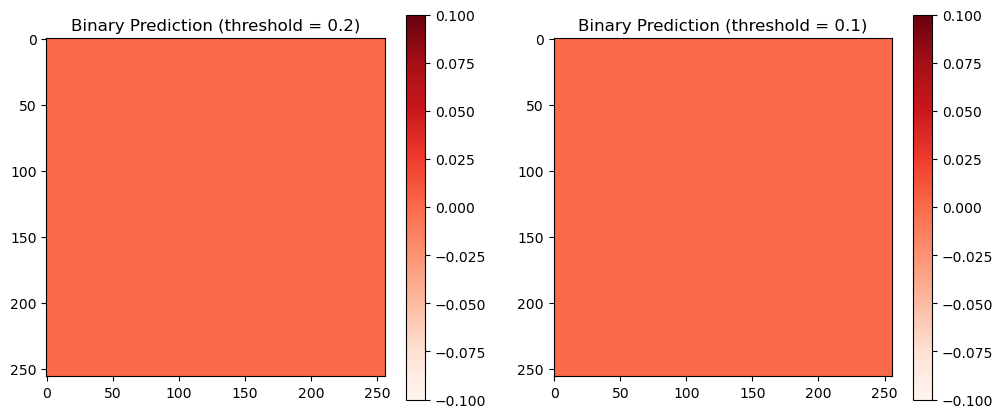

In [139]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.imshow(pred_binary_02, cmap="Reds")
plt.title("Binary Prediction (threshold = 0.2)")
plt.colorbar()

plt.subplot(1, 2, 2)
plt.imshow(pred_binary_01, cmap="Reds")
plt.title("Binary Prediction (threshold = 0.1)")
plt.colorbar()

plt.show()

In [144]:
import torch.nn.functional as F

def weighted_bce_loss(pred, target, pos_weight=5.0):
    pred = pred.clamp(1e-6, 1 - 1e-6)
    loss = - (pos_weight * target * torch.log(pred) + (1 - target) * torch.log(1 - pred))
    return loss.mean()

def combined_loss(pred, target):
    return weighted_bce_loss(pred, target) + dice_loss(pred, target)

In [142]:
pred_soft = pred_patch[0, 0].numpy()

print(pred_soft.min(), pred_soft.max(), pred_soft.mean())

0.0 3.704107e-08 1.5316364e-12


In [145]:
pred_binary = (pred_soft > 0.5).astype(float)

In [146]:
import torch
import torch.nn as nn

class AttentionBlock(nn.Module):
    def __init__(self, g_channels, x_channels, inter_channels):
        super().__init__()

        self.W_g = nn.Sequential(
            nn.Conv2d(g_channels, inter_channels, kernel_size=1),
            nn.BatchNorm2d(inter_channels)
        )

        self.W_x = nn.Sequential(
            nn.Conv2d(x_channels, inter_channels, kernel_size=1),
            nn.BatchNorm2d(inter_channels)
        )

        self.psi = nn.Sequential(
            nn.Conv2d(inter_channels, 1, kernel_size=1),
            nn.BatchNorm2d(1),
            nn.Sigmoid()
        )

        self.relu = nn.ReLU(inplace=True)

    def forward(self, g, x):
        g1 = self.W_g(g)
        x1 = self.W_x(x)

        psi = self.relu(g1 + x1)
        psi = self.psi(psi)

        return x * psi

In [147]:
class AttentionUNet(nn.Module):
    def __init__(self, in_channels=5, out_channels=1):
        super().__init__()

        self.enc1 = nn.Sequential(
            nn.Conv2d(in_channels, 32, 3, padding=1),
            nn.ReLU(),
            nn.Conv2d(32, 32, 3, padding=1),
            nn.ReLU()
        )

        self.pool1 = nn.MaxPool2d(2)

        self.enc2 = nn.Sequential(
            nn.Conv2d(32, 64, 3, padding=1),
            nn.ReLU(),
            nn.Conv2d(64, 64, 3, padding=1),
            nn.ReLU()
        )

        self.up1 = nn.ConvTranspose2d(64, 32, 2, stride=2)

        self.att1 = AttentionBlock(g_channels=32, x_channels=32, inter_channels=16)

        self.dec1 = nn.Sequential(
            nn.Conv2d(64, 32, 3, padding=1),
            nn.ReLU(),
            nn.Conv2d(32, 32, 3, padding=1),
            nn.ReLU()
        )

        self.final = nn.Conv2d(32, out_channels, 1)

    def forward(self, x):
        e1 = self.enc1(x)
        p1 = self.pool1(e1)

        e2 = self.enc2(p1)

        u1 = self.up1(e2)

        e1_att = self.att1(u1, e1)

        cat = torch.cat([u1, e1_att], dim=1)

        d1 = self.dec1(cat)

        out = torch.sigmoid(self.final(d1))
        return out

In [148]:
att_model = AttentionUNet(in_channels=5, out_channels=1)

optimizer = torch.optim.Adam(att_model.parameters(), lr=0.001)

print(type(att_model))

<class '__main__.AttentionUNet'>


In [153]:
import torch
import torch.nn as nn

class AttentionBlock(nn.Module):
    def __init__(self, g_channels, x_channels, inter_channels):
        super().__init__()

        self.W_g = nn.Sequential(
            nn.Conv2d(g_channels, inter_channels, kernel_size=1),
            nn.BatchNorm2d(inter_channels)
        )

        self.W_x = nn.Sequential(
            nn.Conv2d(x_channels, inter_channels, kernel_size=1),
            nn.BatchNorm2d(inter_channels)
        )

        self.psi = nn.Sequential(
            nn.Conv2d(inter_channels, 1, kernel_size=1),
            nn.BatchNorm2d(1),
            nn.Sigmoid()
        )

        self.relu = nn.ReLU(inplace=True)

    def forward(self, g, x):
        g1 = self.W_g(g)
        x1 = self.W_x(x)

        psi = self.relu(g1 + x1)
        psi = self.psi(psi)

        return x * psi


class AttentionUNetDropout(nn.Module):
    def __init__(self, in_channels=5, out_channels=1, dropout_p=0.3):
        super().__init__()

        self.enc1 = nn.Sequential(
            nn.Conv2d(in_channels, 32, 3, padding=1),
            nn.ReLU(),
            nn.Dropout2d(dropout_p),
            nn.Conv2d(32, 32, 3, padding=1),
            nn.ReLU()
        )

        self.pool1 = nn.MaxPool2d(2)

        self.enc2 = nn.Sequential(
            nn.Conv2d(32, 64, 3, padding=1),
            nn.ReLU(),
            nn.Dropout2d(dropout_p),
            nn.Conv2d(64, 64, 3, padding=1),
            nn.ReLU()
        )

        self.up1 = nn.ConvTranspose2d(64, 32, 2, stride=2)

        self.att1 = AttentionBlock(g_channels=32, x_channels=32, inter_channels=16)

        self.dec1 = nn.Sequential(
            nn.Conv2d(64, 32, 3, padding=1),
            nn.ReLU(),
            nn.Dropout2d(dropout_p),
            nn.Conv2d(32, 32, 3, padding=1),
            nn.ReLU()
        )

        self.final = nn.Conv2d(32, out_channels, 1)

    def forward(self, x):
        e1 = self.enc1(x)
        p1 = self.pool1(e1)

        e2 = self.enc2(p1)

        u1 = self.up1(e2)
        e1_att = self.att1(u1, e1)

        cat = torch.cat([u1, e1_att], dim=1)

        d1 = self.dec1(cat)
        out = torch.sigmoid(self.final(d1))

        return out

In [154]:
mc_model = AttentionUNetDropout(in_channels=5, out_channels=1, dropout_p=0.3)

optimizer = torch.optim.Adam(mc_model.parameters(), lr=0.001)

print(type(mc_model))

<class '__main__.AttentionUNetDropout'>


In [157]:
epochs = 10

for epoch in range(epochs):
    mc_model.train()
    epoch_loss = 0.0

    for batch_x, batch_y in train_loader_filtered:
        optimizer.zero_grad()

        outputs = mc_model(batch_x)
        loss = combined_loss(outputs, batch_y)

        loss.backward()
        optimizer.step()

        epoch_loss += loss.item()

    avg_loss = epoch_loss / len(train_loader_filtered)
    print(f"Epoch {epoch+1}/{epochs}, Loss: {avg_loss:.6f}")

NameError: name 'train_loader_filtered' is not defined

In [156]:
selected_indices = [i for i, count in enumerate(positive_counts) if count > 0]

X_train_filtered = torch.tensor(
    np.stack([patches_np[i] for i in selected_indices], axis=0),
    dtype=torch.float32
)

Y_train_filtered = torch.tensor(
    np.array([label_patches[i] for i in selected_indices]),
    dtype=torch.float32
).unsqueeze(1)

print("Filtered X shape:", X_train_filtered.shape)
print("Filtered Y shape:", Y_train_filtered.shape)

ValueError: need at least one array to stack

In [ ]:
sample_patch = X_train_filtered[0:1]

mc_model.train()   # keep dropout ON during inference

mc_predictions = []

for _ in range(10):
    with torch.no_grad():
        pred = mc_model(sample_patch)
        mc_predictions.append(pred[0, 0].numpy())

mc_predictions = np.array(mc_predictions)

print("MC predictions shape:", mc_predictions.shape)

In [ ]:
mean_prediction = np.mean(mc_predictions, axis=0)
uncertainty_map = np.var(mc_predictions, axis=0)

print("Mean prediction shape:", mean_prediction.shape)
print("Uncertainty map shape:", uncertainty_map.shape)
print("Uncertainty min:", uncertainty_map.min())
print("Uncertainty max:", uncertainty_map.max())

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.imshow(mean_prediction, cmap="Reds")
plt.title("Mean Prediction (Segmentation)")
plt.colorbar()

plt.subplot(1, 2, 2)
plt.imshow(uncertainty_map, cmap="viridis")
plt.title("Uncertainty Map")
plt.colorbar()

plt.show()

In [ ]:
mc_model = AttentionUNetDropout(in_channels=5, out_channels=1, dropout_p=0.3)

optimizer = torch.optim.Adam(mc_model.parameters(), lr=0.001)

epochs = 30

for epoch in range(epochs):
    mc_model.train()
    epoch_loss = 0.0

    for batch_x, batch_y in train_loader_filtered:
        optimizer.zero_grad()

        outputs = mc_model(batch_x)
        loss = combined_loss(outputs, batch_y)

        loss.backward()
        optimizer.step()

        epoch_loss += loss.item()

    avg_loss = epoch_loss / len(train_loader_filtered)
    print(f"Epoch {epoch+1}/{epochs}, Loss: {avg_loss:.6f}")

In [ ]:
sample_patch = X_train_filtered[0:1]

mc_model.train()   # keep dropout ON

mc_predictions = []

for _ in range(10):
    with torch.no_grad():
        pred = mc_model(sample_patch)
        mc_predictions.append(pred[0, 0].numpy())

mc_predictions = np.array(mc_predictions)

print("MC predictions shape:", mc_predictions.shape)

In [ ]:
mean_prediction = np.mean(mc_predictions, axis=0)
uncertainty_map = np.var(mc_predictions, axis=0)

print("Mean prediction min:", mean_prediction.min())
print("Mean prediction max:", mean_prediction.max())
print("Uncertainty min:", uncertainty_map.min())
print("Uncertainty max:", uncertainty_map.max())

In [ ]:
from scipy.ndimage import gaussian_filter

mean_prediction_smooth = gaussian_filter(mean_prediction, sigma=1)
uncertainty_smooth = gaussian_filter(uncertainty_map, sigma=1)

print("Smoothed prediction shape:", mean_prediction_smooth.shape)
print("Smoothed uncertainty shape:", uncertainty_smooth.shape)

In [ ]:
threshold = 0.4
binary_prediction = (mean_prediction_smooth > threshold).astype(np.float32)

print("Threshold used:", threshold)
print("Binary unique values:", np.unique(binary_prediction))

In [ ]:
plt.figure(figsize=(18, 5))

plt.subplot(1, 3, 1)
plt.imshow(mean_prediction_smooth, cmap="Reds", vmin=0, vmax=1)
plt.title("Mean Prediction")
plt.colorbar()

plt.subplot(1, 3, 2)
plt.imshow(binary_prediction, cmap="Reds", vmin=0, vmax=1)
plt.title("Binary Segmentation (threshold=0.4)")
plt.colorbar()

plt.subplot(1, 3, 3)
plt.imshow(uncertainty_smooth, cmap="viridis")
plt.title("Uncertainty Map")
plt.colorbar()

plt.show()

In [ ]:
plt.figure(figsize=(18, 5))

plt.subplot(1, 3, 1)
plt.imshow(Y_train_filtered[0, 0].numpy(), cmap="Reds", vmin=0, vmax=1)
plt.title("Ground Truth Label")
plt.colorbar()

plt.subplot(1, 3, 2)
plt.imshow(binary_prediction, cmap="Reds", vmin=0, vmax=1)
plt.title("Improved Binary Prediction")
plt.colorbar()

plt.subplot(1, 3, 3)
plt.imshow(uncertainty_smooth, cmap="viridis")
plt.title("Improved Uncertainty Map")
plt.colorbar()

plt.show()

In [ ]:
plt.figure(figsize=(6, 6))
plt.imshow(binary_prediction, cmap="Reds", vmin=0, vmax=1)
plt.title("Improved Segmentation Map")
plt.colorbar()
plt.savefig("../results/improved_segmentation_map.png", dpi=300, bbox_inches="tight")
plt.show()

plt.figure(figsize=(6, 6))
plt.imshow(uncertainty_smooth, cmap="viridis")
plt.title("Improved Uncertainty Map")
plt.colorbar()
plt.savefig("../results/improved_uncertainty_map.png", dpi=300, bbox_inches="tight")
plt.show()

In [ ]:
from scipy.ndimage import binary_opening, binary_closing

binary_clean = binary_opening(binary_prediction, structure=np.ones((3, 3)))
binary_clean = binary_closing(binary_clean, structure=np.ones((3, 3)))

print("Binary clean unique values:", np.unique(binary_clean))

In [ ]:
from scipy.ndimage import label

labeled_array, num_features = label(binary_clean)

min_region_size = 20
binary_filtered = np.zeros_like(binary_clean)

for region_id in range(1, num_features + 1):
    region = (labeled_array == region_id)
    if region.sum() >= min_region_size:
        binary_filtered[region] = 1

print("Number of connected regions:", num_features)
print("Filtered unique values:", np.unique(binary_filtered))

In [ ]:
uncertainty_threshold = np.percentile(uncertainty_smooth, 75)

confidence_mask = (uncertainty_smooth < uncertainty_threshold).astype(np.float32)

print("Uncertainty threshold:", uncertainty_threshold)
print("Confidence mask unique values:", np.unique(confidence_mask))

In [ ]:
binary_confident = binary_filtered * confidence_mask

print("Confident binary unique values:", np.unique(binary_confident))

In [ ]:
plt.figure(figsize=(20, 5))

plt.subplot(1, 4, 1)
plt.imshow(binary_prediction, cmap="Reds", vmin=0, vmax=1)
plt.title("Original Binary")
plt.colorbar()

plt.subplot(1, 4, 2)
plt.imshow(binary_clean, cmap="Reds", vmin=0, vmax=1)
plt.title("Morphology Cleaned")
plt.colorbar()

plt.subplot(1, 4, 3)
plt.imshow(binary_filtered, cmap="Reds", vmin=0, vmax=1)
plt.title("Small Regions Removed")
plt.colorbar()

plt.subplot(1, 4, 4)
plt.imshow(binary_confident, cmap="Reds", vmin=0, vmax=1)
plt.title("Final Confident Segmentation")
plt.colorbar()

plt.show()

In [ ]:
plt.figure(figsize=(18, 5))

plt.subplot(1, 3, 1)
plt.imshow(Y_train_filtered[0, 0].numpy(), cmap="Reds", vmin=0, vmax=1)
plt.title("Ground Truth Label")
plt.colorbar()

plt.subplot(1, 3, 2)
plt.imshow(binary_confident, cmap="Reds", vmin=0, vmax=1)
plt.title("Refined Final Segmentation")
plt.colorbar()

plt.subplot(1, 3, 3)
plt.imshow(uncertainty_smooth, cmap="viridis")
plt.title("Refined Uncertainty Map")
plt.colorbar()

plt.show()

In [ ]:
plt.figure(figsize=(6, 6))
plt.imshow(binary_confident, cmap="Reds", vmin=0, vmax=1)
plt.title("Refined Final Segmentation")
plt.colorbar()
plt.savefig("../results/refined_final_segmentation.png", dpi=300, bbox_inches="tight")
plt.show()

plt.figure(figsize=(6, 6))
plt.imshow(uncertainty_smooth, cmap="viridis")
plt.title("Refined Final Uncertainty")
plt.colorbar()
plt.savefig("../results/refined_final_uncertainty.png", dpi=300, bbox_inches="tight")
plt.show()

In [ ]:
sample_np = sample_patch[0].numpy()

ndvi_first = sample_np[0]
ndvi_last = sample_np[-1]

ndvi_change = np.abs(ndvi_last - ndvi_first)

print("NDVI change min:", ndvi_change.min())
print("NDVI change max:", ndvi_change.max())

In [ ]:
texture_map = np.abs(ndvi_last - ndvi_last.mean())

print("Texture min:", texture_map.min())
print("Texture max:", texture_map.max())

In [ ]:
def normalize_map(x):
    return (x - x.min()) / (x.max() - x.min() + 1e-8)

ndvi_change_n = normalize_map(ndvi_change)
texture_n = normalize_map(texture_map)
prob_n = normalize_map(mean_prediction_smooth)
uncertainty_n = normalize_map(uncertainty_smooth)

In [ ]:
w1 = 0.35   # NDVI change
w2 = 0.15   # texture
w3 = 0.35   # model probability
w4 = 0.15   # uncertainty

risk_score = (
    w1 * ndvi_change_n +
    w2 * texture_n +
    w3 * prob_n +
    w4 * uncertainty_n
)

print("Risk score min:", risk_score.min())
print("Risk score max:", risk_score.max())

In [ ]:
risk_class = np.zeros_like(risk_score)

risk_class[(risk_score < 0.33)] = 1
risk_class[(risk_score >= 0.33) & (risk_score < 0.66)] = 2
risk_class[(risk_score >= 0.66)] = 3

print("Risk classes:", np.unique(risk_class))

In [ ]:
plt.figure(figsize=(18,5))

plt.subplot(1,3,1)
plt.imshow(binary_confident, cmap="Reds")
plt.title("Final Segmentation")

plt.subplot(1,3,2)
plt.imshow(uncertainty_smooth, cmap="viridis")
plt.title("Uncertainty Map")

plt.subplot(1,3,3)
plt.imshow(risk_class, cmap="coolwarm")
plt.title("Deforestation Risk Map")

plt.show()

In [ ]:
print("binary_confident exists:", 'binary_confident' in globals())
print("Y_train_filtered exists:", 'Y_train_filtered' in globals())

In [ ]:
threshold = 0.4
binary_prediction = (mean_prediction_smooth > threshold).astype(np.float32)

In [ ]:
# Flatten prediction and ground truth
pred = binary_confident.flatten()
gt = Y_train_filtered[0, 0].numpy().flatten()

# Check shapes
print("Pred shape:", pred.shape)
print("GT shape:", gt.shape)

# Compute Intersection
intersection = (pred * gt).sum()

# Compute Union
union = pred.sum() + gt.sum() - intersection

# IoU
iou = intersection / (union + 1e-8)

# Dice Score
dice = (2 * intersection) / (pred.sum() + gt.sum() + 1e-8)

print("IoU Score:", iou)
print("Dice Score:", dice)

In [ ]:
print("mean_prediction_smooth:", 'mean_prediction_smooth' in globals())
print("uncertainty_smooth:", 'uncertainty_smooth' in globals())
print("Y_train_filtered:", 'Y_train_filtered' in globals())

In [ ]:
selected_indices = [i for i, count in enumerate(positive_counts) if count > 0]

X_train_filtered = torch.tensor(
    np.stack([patches_np[i] for i in selected_indices], axis=0),
    dtype=torch.float32
)

Y_train_filtered = torch.tensor(
    np.array([label_patches[i] for i in selected_indices]),
    dtype=torch.float32
).unsqueeze(1)

print("Filtered X shape:", X_train_filtered.shape)
print("Filtered Y shape:", Y_train_filtered.shape)

In [ ]:
sample_patch = X_train_filtered[0:1]
print("Sample patch shape:", sample_patch.shape)

In [ ]:
print("mc_model exists:", 'mc_model' in globals())

In [ ]:
mc_model = AttentionUNetDropout(in_channels=5, out_channels=1, dropout_p=0.3)

optimizer = torch.optim.Adam(mc_model.parameters(), lr=0.001)

epochs = 10

for epoch in range(epochs):
    mc_model.train()
    epoch_loss = 0.0

    for batch_x, batch_y in train_loader_filtered:
        optimizer.zero_grad()
        outputs = mc_model(batch_x)
        loss = combined_loss(outputs, batch_y)
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()

    avg_loss = epoch_loss / len(train_loader_filtered)
    print(f"Epoch {epoch+1}/{epochs}, Loss: {avg_loss:.6f}")

In [ ]:
positive_counts = [patch.sum() for patch in label_patches]

print("Minimum positive pixels:", np.min(positive_counts))
print("Maximum positive pixels:", np.max(positive_counts))
print("Number of empty patches:", np.sum(np.array(positive_counts) == 0))
print("Total patches:", len(positive_counts))